# 📈 Week 6: Interactive Sales Dashboard
This notebook demonstrates advanced data visualization using `seaborn` for statistical analysis and `plotly` for interactivity.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# DATA LOADING & PREP
try:
    df = pd.read_csv("D:\Week6_Project\sales_data.csv")
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Extract Month for time-series analysis
    df['Month'] = df['Date'].dt.month_name().str[:3]
    print("Data successfully loaded and dates formatted!")
except FileNotFoundError:
    print("Error: 'sales_data.csv' not found. Please ensure it is in the correct folder.")

Data successfully loaded and dates formatted!


# Statistical Visualizations (Box & Violin Plots)
Understanding the underlying distribution, density, and outliers of our sales data.

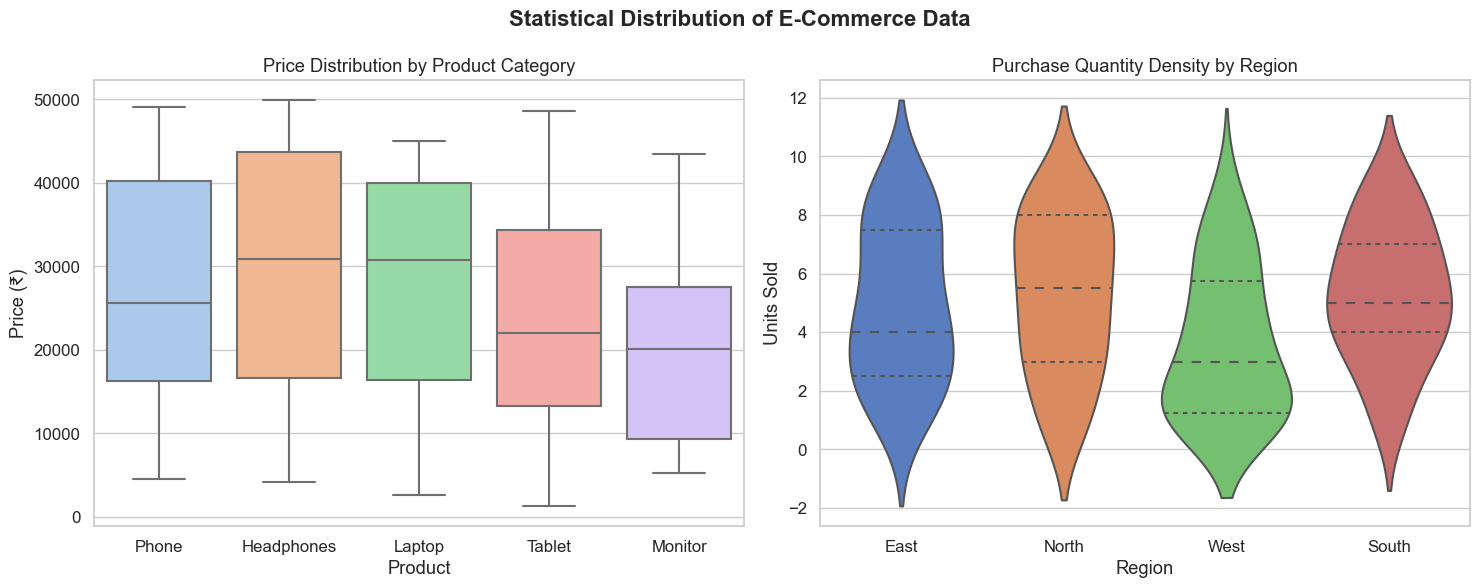

In [8]:
# Create a wide figure to hold two side-by-side statistical plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Statistical Distribution of E-Commerce Data', fontsize=16, fontweight='bold')

# CHART 1: Box Plot (Distribution & Outliers)
sns.boxplot(x='Product', y='Price', data=df, ax=axes[0], palette="pastel")
axes[0].set_title('Price Distribution by Product Category')
axes[0].set_ylabel('Price (₹)')

# CHART 2: Violin Plot (Density & Quartiles)
sns.violinplot(x='Region', y='Quantity', data=df, inner="quartile", ax=axes[1], palette="muted")
axes[1].set_title('Purchase Quantity Density by Region')
axes[1].set_ylabel('Units Sold')

plt.tight_layout()
plt.show()

# Heatmaps & Correlation
Proving the mathematical relationships between numerical columns in our dataset..

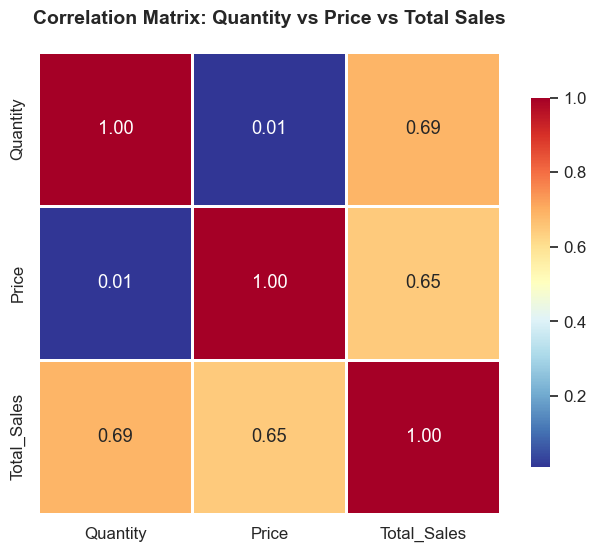

In [9]:
plt.figure(figsize=(8, 6))

# Calculate correlation matrix for numerical data only
numeric_df = df[['Quantity', 'Price', 'Total_Sales']]
corr_matrix = numeric_df.corr()

# CHART 3: Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', fmt=".2f", 
            linewidths=1, linecolor='white', square=True, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix: Quantity vs Price vs Total Sales', fontsize=14, fontweight='bold', pad=20)
plt.show()

# Multi-plot Static Dashboard (2x2 Grid)
Combining multiple insights into a single, cohesive presentation layout..

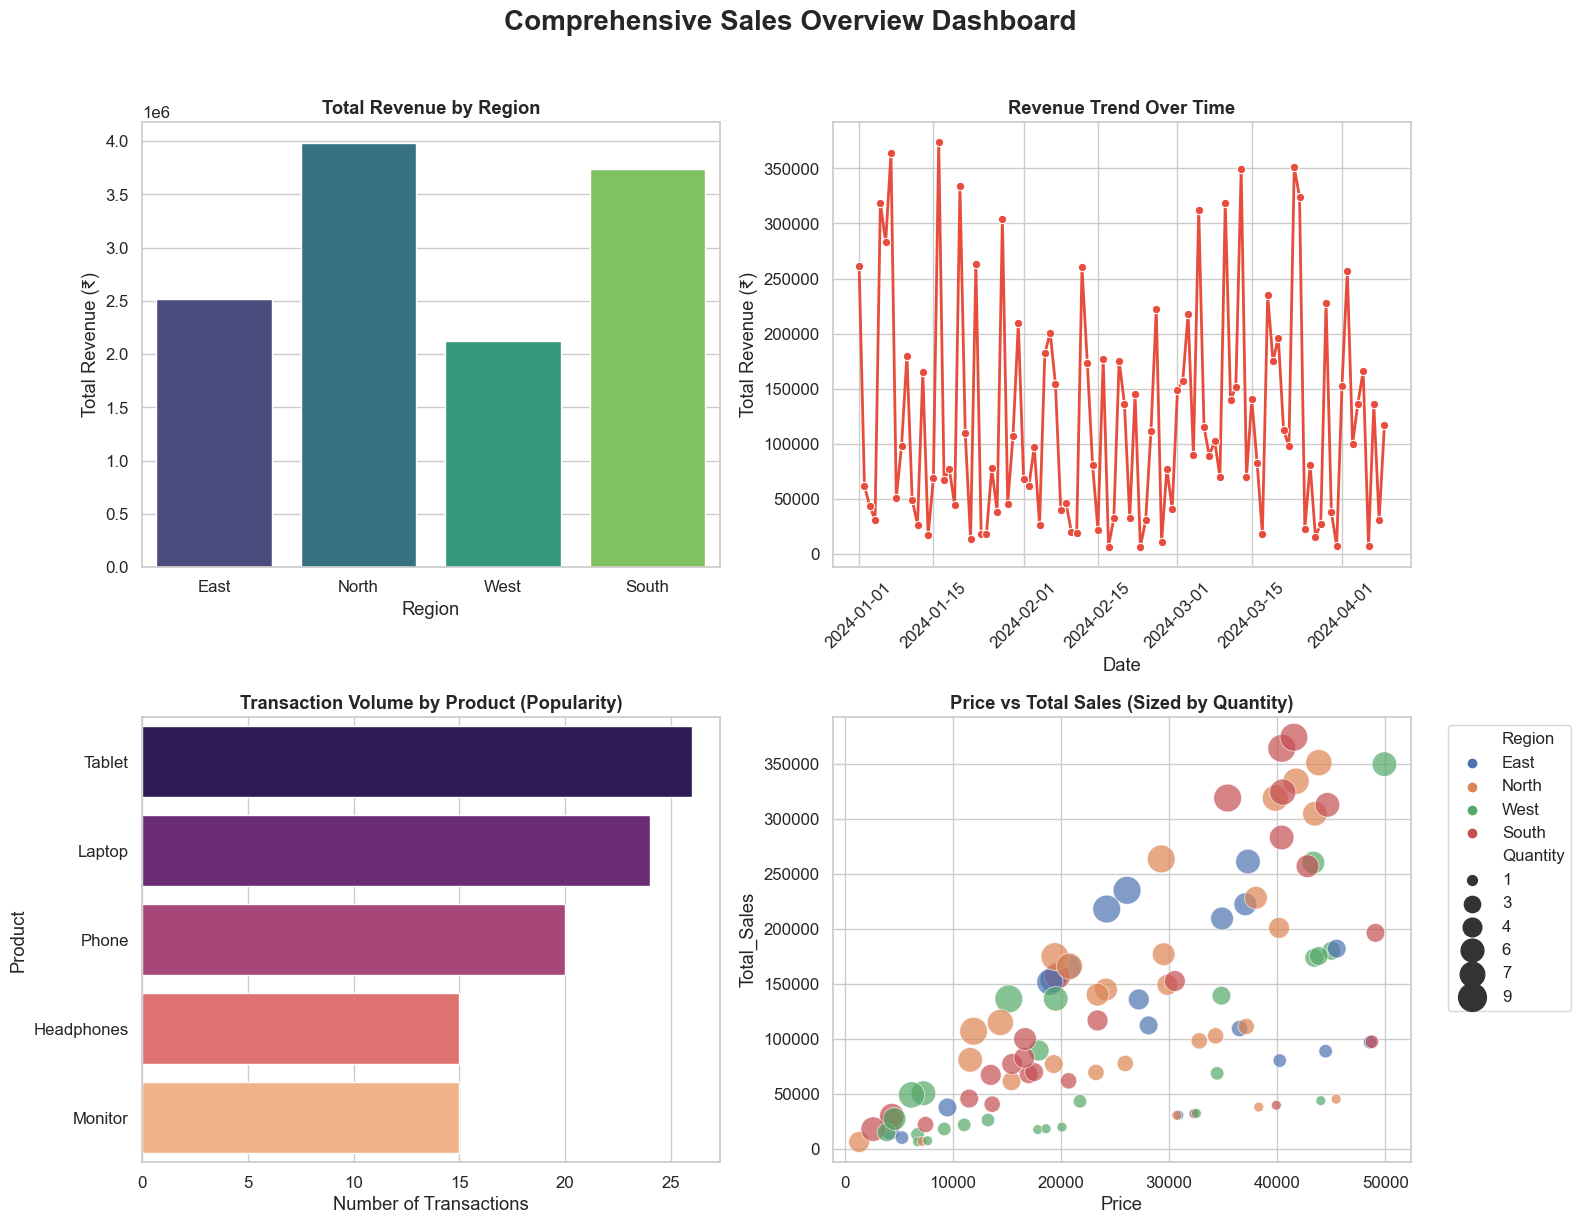

In [10]:
# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comprehensive Sales Overview Dashboard', fontsize=20, fontweight='bold', y=1.02)

# TOP LEFT: Bar Chart (Sales by Region)
sns.barplot(x='Region', y='Total_Sales', data=df, estimator=sum, errorbar=None, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title('Total Revenue by Region', fontweight='bold')
axes[0, 0].set_ylabel('Total Revenue (₹)')

# TOP RIGHT: Line Chart (Sales Trend over Time)
# Grouping by date first to smooth the line
daily_sales = df.groupby('Date')['Total_Sales'].sum().reset_index()
sns.lineplot(x='Date', y='Total_Sales', data=daily_sales, ax=axes[0, 1], color='#e74c3c', linewidth=2, marker='o')
axes[0, 1].set_title('Revenue Trend Over Time', fontweight='bold')
axes[0, 1].set_ylabel('Total Revenue (₹)')
axes[0, 1].tick_params(axis='x', rotation=45)

# BOTTOM LEFT: Count Plot (Customer Segmentation / Product Popularity)
sns.countplot(y='Product', data=df, ax=axes[1, 0], order=df['Product'].value_counts().index, palette="magma")
axes[1, 0].set_title('Transaction Volume by Product (Popularity)', fontweight='bold')
axes[1, 0].set_xlabel('Number of Transactions')

# BOTTOM RIGHT: Scatter Plot (Price vs Sales clustering)
sns.scatterplot(x='Price', y='Total_Sales', hue='Region', size='Quantity', sizes=(50, 400), alpha=0.7, data=df, ax=axes[1, 1])
axes[1, 1].set_title('Price vs Total Sales (Sized by Quantity)', fontweight='bold')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside

plt.tight_layout()
plt.show()

# Interactive Visualizations (Plotly)
Building an interactive, presentation-ready dashboard element with hover effects and dynamic sizing.

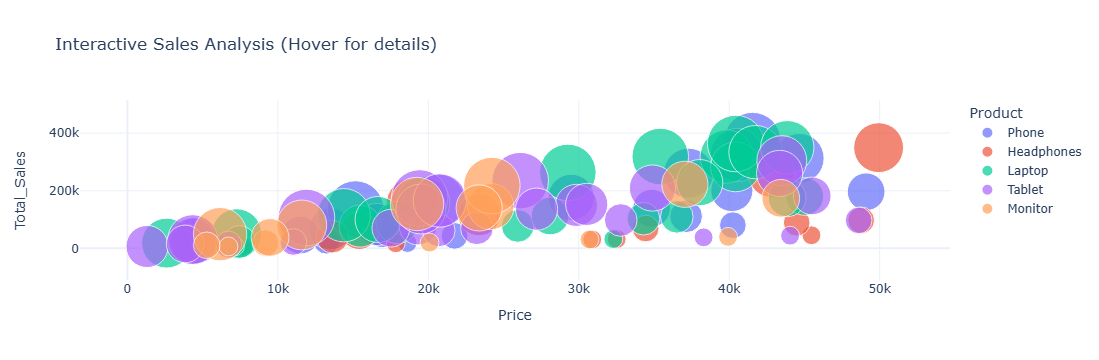

In [12]:
# Create the Plotly figure
fig_plotly = px.scatter(
    df, 
    x="Price", 
    y="Total_Sales", 
    size="Quantity", 
    color="Product",
    hover_name="Region", 
    hover_data=["Date", "Customer_ID"],
    title="Interactive Sales Analysis (Hover for details)",
    size_max=40, 
    template="plotly_white"
)

# Display the interactive chart right inside the notebook!
fig_plotly.show()